# Synapse 参数学习

沿用 Channel/Ion 的 `parameter`、`scale`、`parameterized`，每个示例只有一个可训标量、一条带 spike 的 1 CV 电压轨迹。模型与训练函数在同目录 `synapse_learning.py`，本 notebook 可直接从头执行。

| 目标 | 参数入口 | 梯度路径 | 边界 |
|---|---|---|---|
| ExpSyn `tau`、`e` | 显式构造签名；`synapses.trainable(...)` | 连续状态/电流 | 无有效输入时可以为零 |
| Exp2Syn `tau1`、`tau2` | 同上 | 衰减及动态计算的归一化 factor | 初始值需满足 `0 < tau1 < tau2` |
| Connection `weight` | `connection.trainable(weight=...)` | 浮点事件载荷乘权重 | 固定 NetStim 不需要对事件时间求导 |
| 检测器 `threshold` | `source.trainable(threshold=...)` | 硬事件前向，代理梯度反向 | 相同事件时间格可以对应多个阈值 |
| `delay` | 不开放训练 | 固定队列/路由 | 明确抛出 NotImplementedError |
| 字符串、错误单位/形状 | 不可作为有效数值目标 | 注册/数值运算检查 | 不维护科学参数白名单 |

上穿采用 `last < threshold <= next`，下穿采用 `last > threshold >= next`。到达阈值计一次，在阈值停留或从阈值离开不重复发放。NEURON 9.0.1 的 APCount 使用 `>=`，固定步长 NetCon 使用 `>`；不能将本规则与 NEURON 所有检测器一概视为相同。

训练根与物理运行参数分离：每次 reset 从当前根物化参数，清空动态状态与事件队列，不重置优化器根。参数正值/顺序约束在初始化与注册时检查；优化过程中应由用户选择合适的参数变换维持约束。

In [1]:
import os
os.environ['JAX_PLATFORMS'] = 'cpu'
from pathlib import Path
import sys
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').exists())
sys.path.insert(0, str(root))
import braincell
import brainstate
import brainunit as u
import jax
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from examples.optim.parameter_learning.synapse_learning import DT, build_cell, fit_one
print(f'JAX {jax.__version__}; backend={jax.default_backend()}')


JAX 0.8.0; backend=cpu


## 1. 固定 NetStim 输入：学习 tau、weight

每次只拟合一个因子，从 0.8 开始，目标因子为 1。使用 6 ms 电压轨迹与 100 次 Adam 更新。固定外部事件没有需要学习的上游电压，因此 tau/weight 的连续梯度不依赖事件代理梯度。

## 2. 自连接：学习检测阈值

只学习 `threshold = -20 mV + delta * mV`，delta 从 -10 开始。默认 Cell 的 spike 检测器经 0.1 ms 固定延迟驱动自身 ExpSyn，仍使用电压损失。训练阈值使用代理梯度，不把硬事件的有限差分当作正确梯度。

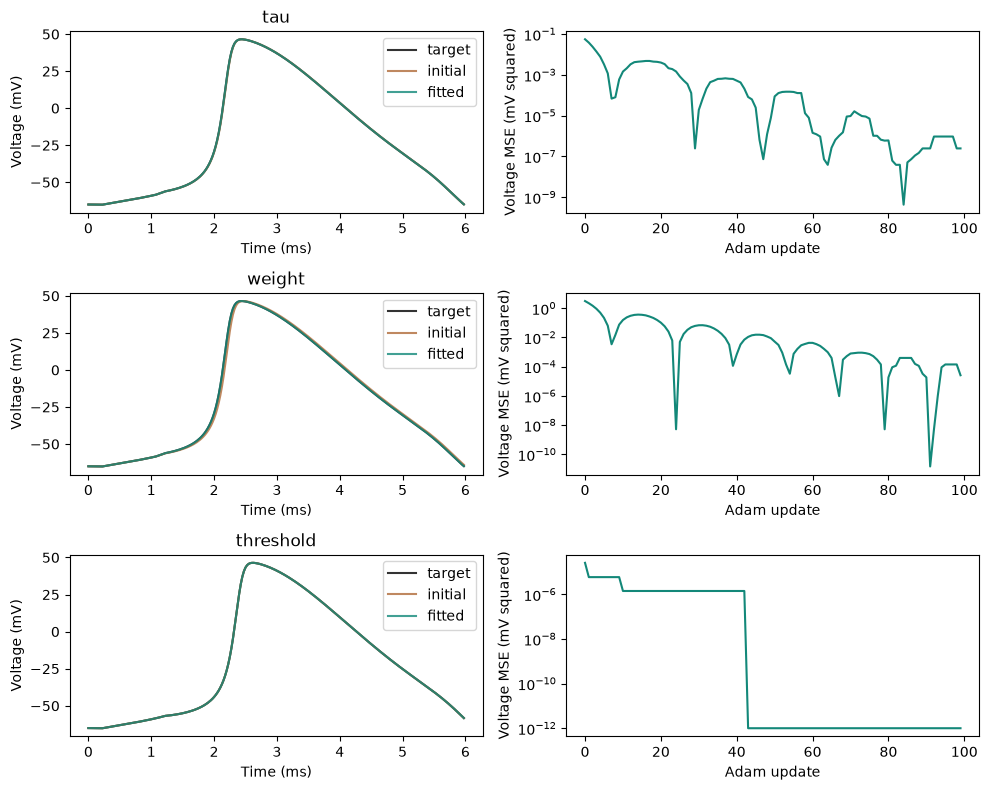

| 参数 | 初始梯度（根坐标） | 初始 MSE | 最终 MSE | 最终根 | 目标 spike 数 |
|---|---:|---:|---:|---:|---:|
| tau | -0.695905 | 0.0564968 | 2.48711e-07 | 1.00125 | 1 |
| weight | -32.5734 | 3.11666 | 9.70201e-07 | 1.00061 | 1 |
| threshold | -0.000121621 | 2.5993e-05 | 0 | -1.41997 | 1 |

threshold 的最终根是 delta，不是阈值本身；相同事件格不要求 delta 精确回到 0。


In [2]:
results = []
with brainstate.environ.context(dt=DT):
    for field in ('tau', 'weight', 'threshold'):  # independent experiments, not simulation steps
        results.append(fit_one(field))
fig, axes = plt.subplots(3, 2, figsize=(10, 8))
for row, result in enumerate(results):
    times = np.arange(result['target'].size) * float(DT / u.ms)
    for key, color in [('target', 'black'), ('initial', '#b06b38'), ('fitted', '#138879')]:
        axes[row, 0].plot(times, result[key], label=key, color=color, alpha=.8)
    axes[row, 0].set(title=result['field'], xlabel='Time (ms)', ylabel='Voltage (mV)')
    axes[row, 0].legend()
    axes[row, 1].semilogy(np.maximum(result['history'], 1e-12), color='#138879')
    axes[row, 1].set(xlabel='Adam update', ylabel='Voltage MSE (mV squared)')
fig.tight_layout()
plt.show()
display(Markdown('| 参数 | 初始梯度（根坐标） | 初始 MSE | 最终 MSE | 最终根 | 目标 spike 数 |\n|---|---:|---:|---:|---:|---:|\n' + '\n'.join(
    f"| {r['field']} | {r['initial_gradient']:.6g} | {r['initial_mse']:.6g} | {r['final_mse']:.6g} | {r['fitted_root']:.6g} | {r['spikes']} |" for r in results)))
print('threshold 的最终根是 delta，不是阈值本身；相同事件格不要求 delta 精确回到 0。')


## 3. 自动报错与零梯度

下面没有输入事件，ExpSyn 的 g 从零开始且保持为零，所以电流对 tau 的梯度为零。这不是注册失败。错误单位、非法时间常数以及 delay 训练会被拒绝。

In [3]:
cell = build_cell()
cell.synapses['syn'].trainable(tau=braincell.trainable.scale(name='tau'))
cell.init_state()
syn = cell.synapses['syn']
node = cell.runtime.get_runtime_node(syn._store.layout_id('ExpSyn'))
def silent_current():
    cell.reset_state()
    return node.current(-65.*u.mV).to_decimal(u.nA).sum()
zero = brainstate.transform.jit(brainstate.transform.grad(
    silent_current, grad_states=cell.trainables.parameters().states()))()['tau']
assert float(zero) == 0.
rows = [f'| tau，无事件 | gradient = {float(zero):g} |']
for label, field, value in [('tau 单位错误', 'tau', 1.*u.mV), ('tau 非正', 'tau', -1.*u.ms), ('name 字符串', 'name', 'text')]:
    bad = build_cell()
    try:
        bad.synapses['syn'].trainable(**{field: braincell.trainable.parameter(value)})
    except (TypeError, ValueError, KeyError) as error:
        rows.append(f'| {label} | {type(error).__name__} |')
        assert not bad.trainables.bindings()
    else:
        raise AssertionError(label)
bad = build_cell()
connection = braincell.connect('input', source=braincell.NetStim(), synapse=bad.synapses['syn'], weight=.001*u.uS)
try:
    connection.trainable(delay=braincell.trainable.parameter(.1*u.ms))
except NotImplementedError as error:
    rows.append(f'| delay | {type(error).__name__} |')
else:
    raise AssertionError('delay unexpectedly trainable')
display(Markdown('| 检查 | 实际结果 |\n|---|---|\n' + '\n'.join(rows)))


| 检查 | 实际结果 |
|---|---|
| tau，无事件 | gradient = 0 |
| tau 单位错误 | ValueError |
| tau 非正 | ValueError |
| name 字符串 | KeyError |
| delay | NotImplementedError |

## 4. BPTT / 完整状态 RTRL

复用已有实验 RTRL，不实现新算法。先比较单 Cell 自连接的电压损失和 spike 损失，再检查 Network。全状态包含突触状态、事件队列及跨 Cell 依赖，参数在一次 rollout 内固定；这里只证明前向敏感度递推兼容，不代表已支持每个时间步更新优化器参数。

spike 损失为 `(spike - 1)^2`，这里只是导数探针，不是生物学目标。某些固定延迟使反馈到达后不再经过代理函数的有效梯度区域，此时 weight 的 spike-loss 梯度可以为零。两种算法必须对此给出相同结果。

In [4]:
from validation.optim.gradient_correctness.autapse import compare
checks = []
with brainstate.environ.context(dt=DT, precision=64):
    for mode in ('voltage', 'spike'):
        for delay_ms in (0., .1):
            result = compare(loss_kind=mode, delay=delay_ms*u.ms)
            checks.append(f"| Cell autapse | {mode} | {delay_ms:g} | {result['max_abs_error']:.3g} | {result['gradients']['weight']:.6g} |")
    result = compare(network=True, paired=True)
    checks.append(f"| Two-Cell Network | voltage | 0.1 | {result['max_abs_error']:.3g} | {result['gradients']['cell.weight']:.6g} |")
display(Markdown('| 模型 | 损失 | 固定 delay (ms) | 最大绝对梯度差 | weight 梯度 |\n|---|---|---:|---:|---:|\n' + '\n'.join(checks)))


| 模型 | 损失 | 固定 delay (ms) | 最大绝对梯度差 | weight 梯度 |
|---|---|---:|---:|---:|
| Cell autapse | voltage | 0 | 3.49e-10 | -741.38 |
| Cell autapse | voltage | 0.1 | 5.24e-10 | -792.68 |
| Cell autapse | spike | 0 | 8.88e-16 | 0.000659412 |
| Cell autapse | spike | 0.1 | 3.33e-15 | 0 |
| Two-Cell Network | voltage | 0.1 | 1.88e-12 | 0 |

## 5. 两个 population，双方参数与双向连接同时可训

A 有 2 个成员，B 有 3 个成员，每个成员仍是 1 CV。A→B 和 B→A 各有 6 个 contact，包含汇聚与发散。A 接收 ExpSyn，B 接收 Exp2Syn。两次错开的电流脉冲确保双方接收反馈后仍有后续放电。

| 区域 | 可训字段 | 梯度验证分组 | 拟合分组 |
|---|---|---|---|
| A、B 的 Na channel | g_max、V_sh | 每成员独立 | 各 population 内共享 |
| A、B 的 SodiumFixed | E | 每成员独立 | 各 population 内共享 |
| A 的 ExpSyn | tau、e | 每突触独立 | A 内共享 |
| B 的 Exp2Syn | tau1、tau2、e | 每突触独立 | B 内共享 |
| A、B 的检测器 | threshold | 每成员独立 | 各 population 内共享 |
| A→B、B→A | weight | 每 contact 独立 | 各方向内共享 |

完整梯度验证有 45 个标量自由度，联合拟合保留 15 个。delay 固定且异质，训练中不改变路由。此处是小型双向网络验证，不是对所有机制或网络规模的穷举证明。

下方 gmax、ion、tau、weight 参数根表示无量纲缩放因子；shift、reversal、threshold 根表示以 mV 计的偏移，不是绝对电压。A.weight 对应 B→A，B.weight 对应 A→B，名称按接收方归属。

In [5]:
from validation.optim.gradient_correctness.bidirectional import (
    build as build_network, gradient_comparison, fit as fit_network, DT as NETWORK_DT,
)
with brainstate.environ.context(dt=NETWORK_DT, precision=64):
    network_probe = build_network()
    activity = brainstate.transform.jit(network_probe.rollout)()
    comparison = gradient_comparison()
counts = np.asarray(activity['spike']).sum(axis=0)
assert np.all(counts >= 2), counts
display(Markdown('| 成员 | spike 数 | 最大接收电导 (uS) |\n|---|---:|---:|\n' + '\n'.join(
    f'| {name} | {counts[i]:g} | {np.asarray(activity["conductance"])[:, i].max():.6g} |'
    for i, name in enumerate(['A0', 'A1', 'B0', 'B1', 'B2']))))
display(Markdown('| 参数根 | 形状 | 最大绝对梯度 | BPTT/RTRL 最大绝对差 |\n|---|---|---:|---:|\n' + '\n'.join(
    f'| {name} | {gradient.shape} | {np.abs(gradient).max():.6g} | {comparison["errors"][name]:.3g} |'
    for name, gradient in comparison['gradients'].items())))
print('总梯度坐标数:', sum(value.size for value in comparison['gradients'].values()))


| 成员 | spike 数 | 最大接收电导 (uS) |
|---|---:|---:|
| A0 | 2 | 0.00112587 |
| A1 | 2 | 0.00123126 |
| B0 | 2 | 0.000751331 |
| B1 | 2 | 0.0008344 |
| B2 | 2 | 0.0009164 |

| 参数根 | 形状 | 最大绝对梯度 | BPTT/RTRL 最大绝对差 |
|---|---|---:|---:|
| A.gmax | (2,) | 70371.5 | 3.35e-10 |
| A.ion | (2,) | 105331 | 2.33e-10 |
| A.reversal | (2,) | 30.3741 | 1.99e-13 |
| A.shift | (2,) | 4555.1 | 2.22e-10 |
| A.tau | (2,) | 2669.05 | 3.37e-11 |
| A.threshold | (2,) | 38.4637 | 5.08e-13 |
| A.weight | (6,) | 566.737 | 3.07e-12 |
| B.gmax | (3,) | 60480.7 | 1.16e-10 |
| B.ion | (3,) | 105668 | 1.16e-10 |
| B.reversal | (3,) | 121.859 | 9.95e-13 |
| B.shift | (3,) | 743.612 | 4.34e-11 |
| B.tau1 | (3,) | 450.032 | 4.04e-12 |
| B.tau2 | (3,) | 1562.53 | 4.32e-12 |
| B.threshold | (3,) | 183.281 | 1.85e-12 |
| B.weight | (6,) | 1567.9 | 1.91e-11 |

总梯度坐标数: 45


### 联合拟合：BPTT 与完整 RTRL

两个算法从相同的 15 个扰动参数开始，各训练 100 个 epoch。每次 rollout 内参数固定，epoch 之间更新。两边 channel、ion、synapse、threshold 和双向 weight 都交给优化器；是否唯一恢复参数不是验收条件。

测试文件另外覆盖仅 A / 仅 B 损失、截断 event 反向但保留前向、共享参数梯度求和、不同延迟和投递后端、前缀梯度及跨 population / 队列敏感度。

| 方法 | 初始 MSE | 最终 MSE | 最终/初始 |
|---|---:|---:|---:|
| bptt | 25.5107 | 0.104226 | 0.0040856 |
| rtrl | 25.5107 | 0.104226 | 0.0040856 |

| 参数根（物理坐标） | 初值 | BPTT 拟合 | RTRL 拟合 |
|---|---:|---:|---:|
| A.gmax | 0.98 | 1.02354 | 1.02354 |
| A.shift | 0.25 | 0.102729 | 0.102729 |
| A.ion | 0.98 | 1.00073 | 1.00073 |
| A.tau | 0.98 | 1.08462 | 1.08462 |
| A.reversal | 0.25 | 0.336268 | 0.336268 |
| A.threshold | 0.25 | 0.155479 | 0.155479 |
| A.weight | 0.98 | 1.07271 | 1.07271 |
| B.gmax | 1.02 | 1.01933 | 1.01933 |
| B.shift | 0.25 | 0.149915 | 0.149915 |
| B.ion | 1.02 | 0.989411 | 0.989411 |
| B.tau1 | 1.02 | 0.973852 | 0.973852 |
| B.tau2 | 1.02 | 1.01879 | 1.01879 |
| B.reversal | 0.25 | 0.332946 | 0.332946 |
| B.threshold | 0.25 | 0.0432725 | 0.0432725 |
| B.weight | 1.02 | 1.0633 | 1.0633 |

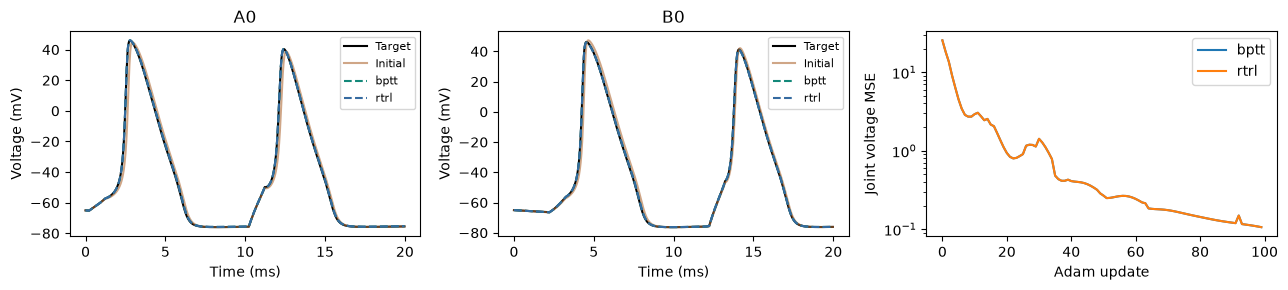

In [6]:
network_fits = []
with brainstate.environ.context(dt=NETWORK_DT, precision=64):
    for method in ('bptt', 'rtrl'):
        result = fit_network(method=method, epochs=100)
        assert np.isfinite(result['history']).all()
        assert result['final_mse'] < .1 * result['initial_mse']
        network_fits.append(result)
display(Markdown('| 方法 | 初始 MSE | 最终 MSE | 最终/初始 |\n|---|---:|---:|---:|\n' + '\n'.join(
    f"| {r['method']} | {r['initial_mse']:.6g} | {r['final_mse']:.6g} | {r['final_mse']/r['initial_mse']:.6g} |" for r in network_fits)))
display(Markdown('| 参数根（物理坐标） | 初值 | BPTT 拟合 | RTRL 拟合 |\n|---|---:|---:|---:|\n' + '\n'.join(
    f'| {name} | {float(value):.6g} | {float(network_fits[0]["fitted_roots"][name]):.6g} | {float(network_fits[1]["fitted_roots"][name]):.6g} |'
    for name, value in network_fits[0]['initial_roots'].items())))
fig, axes = plt.subplots(1, 3, figsize=(13, 3))
times = np.arange(network_fits[0]['target'].shape[0])*float(NETWORK_DT/u.ms)
for axis, member, title in [(axes[0], 0, 'A0'), (axes[1], 2, 'B0')]:
    axis.plot(times, network_fits[0]['target'][:, member], color='black', label='Target')
    axis.plot(times, network_fits[0]['initial'][:, member], color='#b06b38', alpha=.6, label='Initial')
    for result, color in zip(network_fits, ['#138879', '#356aa0']):
        axis.plot(times, result['fitted'][:, member], color=color, linestyle='--', label=result['method'])
    axis.set(title=title, xlabel='Time (ms)', ylabel='Voltage (mV)')
    axis.legend(fontsize=8)
for result in network_fits:
    axes[2].semilogy(result['history'], label=result['method'])
axes[2].set(xlabel='Adam update', ylabel='Joint voltage MSE')
axes[2].legend()
fig.tight_layout()
plt.show()
